In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

import copy
import platform
import subprocess
import json
from io import StringIO
import numpy as np
import pandas as pd
import networkx as nx
from networkx.readwrite import json_graph
from pathlib import Path


from core.html_from_assignments import NMRProblem
import utils.json_utils as json_utils

import core.nmrsolution as nmrsolution
# from globals import svgDimensions

from config.globals import SVG_DIMENSIONS as svgDimensions
from core.simulated_annealing_symmetry import SimulatedAnnealing2

import rdkit
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import Draw

from matplotlib import pyplot as plt

In [3]:
%matplotlib inline

In [4]:
platform.system()

'Windows'

In [5]:
if platform.system() == "Darwin":
    # read json  input files
    pass

elif platform.system() == "Windows":
    fn_json = Path(r"C:\Users\vsmw51\OneDrive - Durham University\projects\programming\2025\python\awh\bruker_data_sets\E72507_04164043_propyl_benzoate\04164043\04164043_jeol_inputdata.json")
    fn_json = Path(r"Y:\downloads\Eric\student_projects\2025\simpleNMR_examples\Cytochalasin-B-kate\Cytochalasin-B-kate_assignments_mresnova.json")
    fn_json = Path(r"Y:\downloads\Eric\student_projects\2026\Kira_wallace\PGS_gzjq25_17130922_E72607_KLW123\PGS_gzjq25_17130922_E72607_KLW123_EEH_assignments_mresnova.json")

In [42]:
print(fn_json, "\n", fn_json.exists())

Y:\downloads\Eric\student_projects\2026\Kira_wallace\PGS_gzjq25_17130922_E72607_KLW123\PGS_gzjq25_17130922_E72607_KLW123_EEH_assignments_mresnova.json 
 True


In [43]:
with open(fn_json, 'r') as f:
    json_data = json.load(f)

In [44]:
problemdata_json = NMRProblem.from_mnova_dict(json_data)

2026-07-24 09:33:45.714 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: hostname
2026-07-24 09:33:45.717 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: PGS_gzjq25_17130922.10.fid
2026-07-24 09:33:45.720 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: PureShift
2026-07-24 09:33:45.723 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: SKIP
2026-07-24 09:33:45.724 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: SKIP
2026-07-24 09:33:45.724 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: exptIdentifiers
2026-07-24 09:33:45.725 | DEBUG    | core.html_from_assignments:create_dataframes_from_mresnova_json:447 - Skipping dataset: ml
2026-07-24 09:33:45.730 | DEBUG    | core.html_fro

In [45]:
solution = nmrsolution.NMRsolution(problemdata_json)

2026-07-24 09:33:47.099 | DEBUG    | core.expectedmolecule:__init__:144 - molprops_df BEFORE merge:
    idx  atom_idx  implicitHs  totalNumHs  degree  hybridization  aromatic
0     0         0           0           0       3              3      True
1     1         1           0           0       3              3      True
2     2         2           1           1       2              3      True
3     3         3           0           0       3              3      True
4     4         4           1           1       2              3      True
5     5         5           1           1       2              3      True
6     6         6           0           0       3              3      True
7     7         7           1           1       2              3      True
8     8         8           1           1       2              3      True
9    11        11           2           2       2              4     False
10   12        12           2           2       2              4     False


Representative atoms for sym_molprops_df:
 [0, 1, 2, 3, 4, 5, 6, 7, 8, 11, 12, 13, 19, 18, 20, 22, 23, 24, 25, 26]
self.sym_molprops_df AFTER refresh:
     atom_idx atomNumber     ppm
idx                             
0           0          1  117.50
1           1          2  149.20
2           2          3  127.40
3           3          4  133.20
4           4          5  123.60
5           5          6  124.30
6           6          7  141.99
7           7          8   98.70
8           8          9  151.80
11         11         12   43.77
12         12         13   25.60
13         13         14   55.80
19         19         20   53.08
18         18         19   44.20
20         20         21  170.79
22         22         23   33.21
23         23         24   24.78
24         24         25   31.97
25         25         26   22.86
26         26         27   14.05


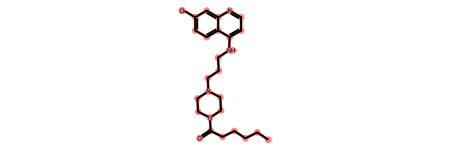

In [46]:
solution.expected_molecule

In [47]:
solution.nmrsolution_failed

False

In [48]:
ok, msg = solution.init_class_from_json()

2026-07-24 09:33:49.498 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 1
2026-07-24 09:33:49.499 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 2
2026-07-24 09:33:49.500 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 3
2026-07-24 09:33:49.501 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 4
2026-07-24 09:33:49.502 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 5
2026-07-24 09:33:49.504 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 6
2026-07-24 09:33:49.504 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 7
2026-07-24 09:33:49.505 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 8
2026-07-24 09:33:49.507 | DEBUG    | core.nmrsolution:init_class_from_json:2199 - Indexing HSQC row: 9
2026-07-24 09:33:49.508 | DEBUG    | core.nmrsolution:init_class_from_jso

In [49]:
ok

True

In [50]:
rtn_msg, rtn_num = solution.assign_CH3_CH2_CH1_overall()

2026-07-24 09:33:53.778 | DEBUG    | core.nmrsolution:assign_CH3_CH2_CH1_overall:258 - CH3/CH2/CH1 chain: running 'Annotations'
2026-07-24 09:33:53.783 | DEBUG    | core.nmrsolution:assign_CH3_CH2_CH1_overall:258 - CH3/CH2/CH1 chain: running 'DoubleDept'
2026-07-24 09:33:53.789 | INFO     | core.nmrsolution:assign_CH3_CH2_CH1_overall:253 - CH3/CH2/CH1 assignment complete after 'H1' step


In [51]:
solution.c13

,ppm,numProtons,attached_protons,CH0,CH1,CH2,CH3,CH3CH1,quaternary,ppmH1s,max_bonds,label,f2C_i,f1C_i,f1_i,f2_i
1,171.776438,-1,0,False,False,False,False,False,False,None,4,C1,C1,C1,1,1
2,151.805809,-1,0,False,False,False,False,False,False,None,4,C2,C2,C2,2,2
3,149.170712,-1,0,False,False,False,False,False,False,None,4,C3,C3,C3,3,3
4,146.195953,-1,0,False,False,False,False,False,False,None,4,C4,C4,C4,4,4
5,136.100429,-1,0,False,False,False,False,False,False,None,4,C5,C5,C5,5,5
6,126.261607,-1,0,False,False,False,False,False,False,None,4,C6,C6,C6,6,6
7,125.624672,-1,0,False,False,False,False,False,False,None,4,C7,C7,C7,7,7
8,122.613100,-1,0,False,False,False,False,False,False,None,4,C8,C8,C8,8,8
9,116.881646,-1,0,False,False,False,False,False,False,None,4,C9,C9,C9,9,9
10,98.367576,-1,0,False,False,False,False,False,False,None,4,C10,C10,C10,10,10


In [52]:
solution.hsqc.columns

Index(['f2_ppm', 'f1_ppm', 'intensity', 'signaltype', 'Annotation', 'f1_i',
       'f2_i', 'f2p_i', 'f1C_i', 'f2H_i', 'f2Cp_i', 'f2p_ppm', 'CH2', 'CH3CH1',
       'CH3', 'CH1', 'CH0', 'quaternary', 'numProtons', 'attached_protons',
       'f2_integral', 'f1_ppm_orig', 'f1_ppm_prob', 'f2_ppm_orig',
       'f2_ppm_prob', 'integral'],
      dtype='object')

In [53]:
solution.hsqc[['f2_ppm', 'f1_ppm', 'f2Cp_i', 'f1C_i', 'numProtons']]

,f2_ppm,f1_ppm,f2Cp_i,f1C_i,numProtons
1,8.422304,149.170712,C3,C3,1
2,7.999925,126.261607,C6,C6,1
3,7.987683,122.613100,C8,C8,1
4,7.353265,125.624672,C7,C7,1
5,6.408582,98.367576,C10,C10,1
6,3.725851,41.436174,C18,C18,2
7,3.563970,45.532829,C16,C16,2
8,3.479389,43.448857,C17,C17,2
9,3.303787,59.087799,C11,C11,2
10,2.616985,57.552491,C12,C12,2


In [54]:
solution.hmbc[['f2_ppm', 'f1_ppm', 'f2p_i', 'f1_i']]

,f2_ppm,f1_ppm,f2p_i,f1_i
1,8.422304,151.805809,3,2
2,8.422304,146.195953,3,4
3,8.422304,98.367576,3,10
4,7.999925,146.195953,6,4
5,7.999925,136.100429,6,5
6,7.999925,125.624672,6,7
7,7.999925,116.881646,6,9
8,7.987683,151.805809,8,2
9,7.987683,136.100429,8,5
10,7.987683,146.195953,8,4


In [55]:
solution.cosy.columns

Index(['f1_ppm', 'f2_ppm', 'intensity', 'f1_i', 'f1p_i', 'f2_i', 'f2p_i',
       'f1p_ppm', 'f2p_ppm', 'f1H_i', 'f2H_i', 'f1Cp_i', 'f2Cp_i',
       'f1_ppm_orig', 'f1_ppm_prob', 'f2_ppm_orig', 'f2_ppm_prob'],
      dtype='object')

In [56]:
solution.cosy[['f2_ppm', 'f1_ppm', 'f2p_i', 'f1p_i']].head()

,f2_ppm,f1_ppm,f2p_i,f1p_i
0,8.422304,6.408582,3,10
1,7.987683,7.353265,8,7
2,3.725851,2.517054,18,15
3,3.563970,2.537975,16,13
4,3.479389,2.003171,17,22


In [57]:
solution.hsqc_clipcosy_df.head()

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,8.422304,98.367576,-8.818945,0,
2,7.991797,125.634205,-12.218466,0,
3,7.351097,122.613100,-12.333221,0,
4,6.408582,149.170712,-6.455435,0,
5,3.724289,53.195620,-8.652298,0,


In [58]:
solution.hsqc_clipcosy[['f2_ppm', 'f1_ppm', 'f2p_i', 'f1p_i']].head()

,f2_ppm,f1_ppm,f2p_i,f1p_i
1,8.422304,6.408582,3,10
2,7.987683,7.353265,8,7
3,7.353265,7.987683,7,8
4,6.408582,8.422304,10,3
5,3.725851,2.517054,18,15


In [59]:
# Build a mapping from HSQC f1_i -> numProtons (use max in case of duplicate f1_i entries)
hsqc_numprotons_map = (
    solution.hsqc.groupby("f1_i")["numProtons"]
    .max()
)

# Populate c13 numProtons using c13.f1_i
solution.c13["numProtons"] = solution.c13["f1_i"].map(hsqc_numprotons_map).fillna(solution.c13["numProtons"])

# Any remaining -1 values should be set to 0
solution.c13.loc[solution.c13["numProtons"] == -1, "numProtons"] = 0

solution.c13[["f1_i", "numProtons"]].head()

,f1_i,numProtons
1,1,0.0
2,2,0.0
3,3,1.0
4,4,0.0
5,5,0.0


In [60]:
solution.c13[["ppm", "f1_i", "numProtons"]]

,ppm,f1_i,numProtons
1,171.776438,1,0.0
2,151.805809,2,0.0
3,149.170712,3,1.0
4,146.195953,4,0.0
5,136.100429,5,0.0
6,126.261607,6,1.0
7,125.624672,7,1.0
8,122.613100,8,1.0
9,116.881646,9,0.0
10,98.367576,10,1.0


In [61]:
# Build a graph from solution.c13 using f1_i as node id
G_c13 = nx.Graph()

for row in solution.c13[["f1_i", "ppm", "numProtons"]].dropna(subset=["f1_i"]).drop_duplicates("f1_i").itertuples(index=False):
    G_c13.add_node(int(row.f1_i), ppm=float(row.ppm), numProtons=int(row.numProtons))

print(f"Created G_c13 with {G_c13.number_of_nodes()} nodes and {G_c13.number_of_edges()} edges.")
list(G_c13.nodes(data=True))[:10]

Created G_c13 with 26 nodes and 0 edges.


[(1, {'ppm': 171.77643750270965, 'numProtons': 0}),
 (2, {'ppm': 151.805809048248, 'numProtons': 0}),
 (3, {'ppm': 149.17071221307995, 'numProtons': 1}),
 (4, {'ppm': 146.19595257022488, 'numProtons': 0}),
 (5, {'ppm': 136.10042926602836, 'numProtons': 0}),
 (6, {'ppm': 126.26160725237223, 'numProtons': 1}),
 (7, {'ppm': 125.62467210041135, 'numProtons': 1}),
 (8, {'ppm': 122.61309991138766, 'numProtons': 1}),
 (9, {'ppm': 116.88164591365643, 'numProtons': 0}),
 (10, {'ppm': 98.36757630049854, 'numProtons': 1})]

In [62]:
len(G_c13.nodes(data=True))

26

In [63]:
# Add edges to the network based on HMBC correlations and set the edge weight to 1 and with an edge attribute of 'HMBC' to True using columns f1_i and f2p_i
for row in solution.hmbc[["f1_i", "f2p_i"]].dropna(subset=["f1_i", "f2p_i"]).itertuples(index=False):
    G_c13.add_edge(int(row.f1_i), int(row.f2p_i), weight=1, HMBC=True)


In [64]:
# Add edges to the network based on COSY correlations using columns f2p_i and f1p_i
for row in solution.cosy[["f2p_i", "f1p_i"]].dropna(subset=["f2p_i", "f1p_i"]).itertuples(index=False):
    if G_c13.has_edge(int(row.f2p_i), int(row.f1p_i)):
        G_c13[int(row.f2p_i)][int(row.f1p_i)]['COSY'] = True
    else:
        G_c13.add_edge(int(row.f2p_i), int(row.f1p_i), weight=1, COSY=True)

In [65]:
# Add edges to the network based on HSQC_CLIPCOSY correlations using columns f2p_i and f1p_i
for row in solution.hsqc_clipcosy[["f2p_i", "f1p_i"]].dropna(subset=["f2p_i", "f1p_i"]).itertuples(index=False):
    if G_c13.has_edge(int(row.f2p_i), int(row.f1p_i)):
        G_c13[int(row.f2p_i)][int(row.f1p_i)]['HSQC_CLIPCOSY'] = True
    else:
        G_c13.add_edge(int(row.f2p_i), int(row.f1p_i), weight=1, COSY=True)


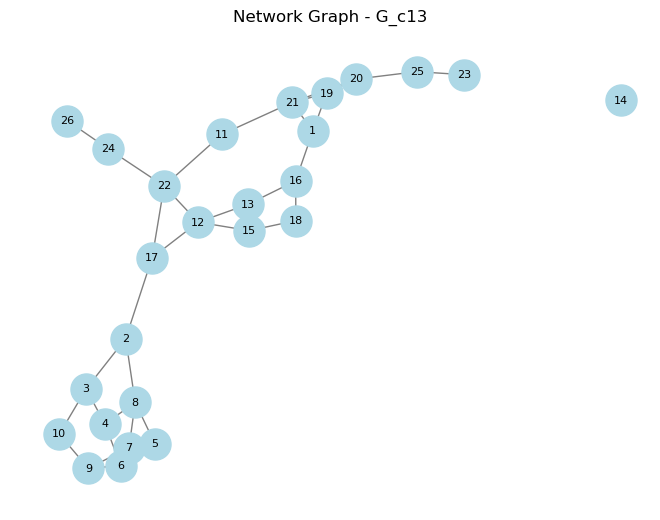

In [66]:
nx.draw(G_c13, with_labels=True, node_color='lightblue', node_size=500, font_size=8, edge_color='gray')
plt.title("Network Graph - G_c13")
plt.show()

In [67]:
G_cosy = nx.Graph()
G_cosy.add_nodes_from(G_c13.nodes(data=True))
G_cosy.add_edges_from(
    (u, v, d) for u, v, d in G_c13.edges(data=True) if d.get('COSY', False)
)
print(f"G_cosy: {G_cosy.number_of_nodes()} nodes, {G_cosy.number_of_edges()} edges")

G_cosy: 26 nodes, 14 edges


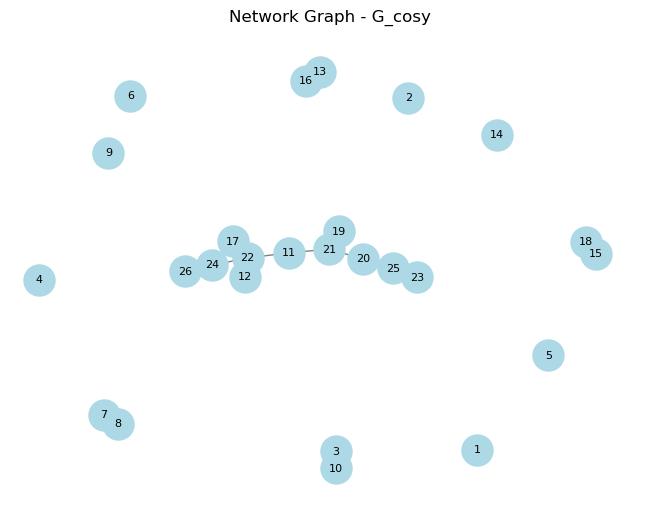

In [68]:
nx.draw(G_cosy, with_labels=True, node_color='lightblue', node_size=500, font_size=8, edge_color='gray')
plt.title("Network Graph - G_cosy")
plt.show()

Removed 7 isolated nodes
G_cosy now has 19 nodes and 14 edges


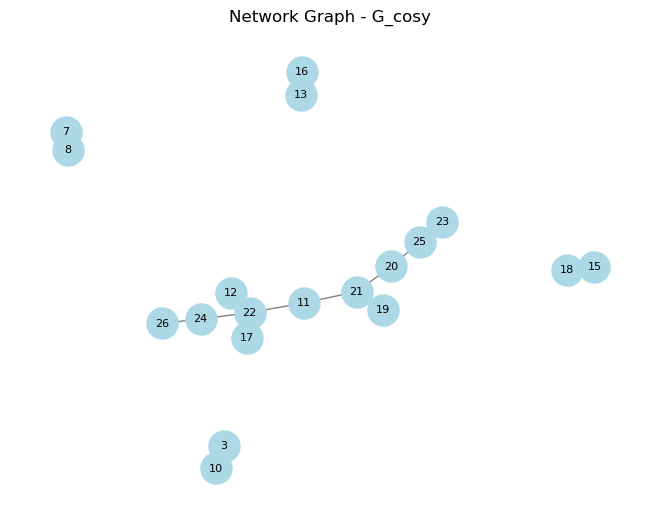

In [69]:
# Remove all isolated nodes (nodes with no edges) from G_cosy
isolated_nodes = list(nx.isolates(G_cosy))
G_cosy.remove_nodes_from(isolated_nodes)

print(f"Removed {len(isolated_nodes)} isolated nodes")
print(f"G_cosy now has {G_cosy.number_of_nodes()} nodes and {G_cosy.number_of_edges()} edges")

nx.draw(G_cosy, with_labels=True, node_color='lightblue', node_size=500, font_size=8, edge_color='gray')
plt.title("Network Graph - G_cosy")
plt.show()

In [71]:
solution.c13[solution.c13.f1_i.isin([23, 25, 20, 21])]

,ppm,numProtons,attached_protons,CH0,CH1,CH2,CH3,CH3CH1,quaternary,ppmH1s,max_bonds,label,f2C_i,f1C_i,f1_i,f2_i
20,31.652791,2.0,0,False,False,False,False,False,False,None,4,C20,C20,C20,20,20
21,25.028455,2.0,0,False,False,False,False,False,False,None,4,C21,C21,C21,21,21
23,22.489701,2.0,0,False,False,False,False,False,False,None,4,C23,C23,C23,23,23
25,13.980410,3.0,0,False,False,False,False,False,False,None,4,C25,C25,C25,25,25


In [70]:
solution.c13[solution.c13.f1_i.isin([22, 24, 26, 11])]

,ppm,numProtons,attached_protons,CH0,CH1,CH2,CH3,CH3CH1,quaternary,ppmH1s,max_bonds,label,f2C_i,f1C_i,f1_i,f2_i
11,59.087799,2.0,0,False,False,False,False,False,False,None,4,C11,C11,C11,11,11
22,24.100145,2.0,0,False,False,False,False,False,False,None,4,C22,C22,C22,22,22
24,19.777250,2.0,0,False,False,False,False,False,False,None,4,C24,C24,C24,24,24
26,13.661512,3.0,0,False,False,False,False,False,False,None,4,C26,C26,C26,26,26


In [72]:
solution.cosy_df

,f2_ppm,f1_ppm,intensity,signaltype,Annotation
1,8.422304,6.408582,74.264076,0,
2,7.987683,7.353265,29.319361,0,
3,3.723618,2.516091,25.144178,0,
4,3.563807,2.539759,23.144825,0,
5,3.479135,2.003171,37.479271,0,
6,3.303787,1.684817,11.919174,0,
7,2.616375,2.003171,15.748705,0,
8,2.539759,3.563807,14.096075,0,
9,2.516091,3.723618,8.744544,0,
10,2.350891,1.659111,30.097591,0,


In [73]:
solution.cosy

,f1_ppm,f2_ppm,intensity,f1_i,f1p_i,f2_i,f2p_i,f1p_ppm,f2p_ppm,f1H_i,f2H_i,f1Cp_i,f2Cp_i,f1_ppm_orig,f1_ppm_prob,f2_ppm_orig,f2_ppm_prob
0,6.408582,8.422304,74.264076,5,10,1,3,98.367576,149.170712,H5,H1,C10,C3,6.408582,79.788456,8.422304,79.788456
1,7.353265,7.987683,29.319361,4,7,3,8,125.624672,122.613100,H4,H3,C7,C8,7.353265,79.788456,7.987683,79.788456
2,2.517054,3.725851,25.144178,12,15,6,18,53.191578,41.436174,H12,H6,C15,C18,2.516091,78.320738,3.723618,72.218445
3,2.537975,3.563970,23.144825,11,13,7,16,53.739917,45.532829,H11,H7,C13,C16,2.539759,74.869905,3.563807,79.746250
4,2.003171,3.479389,37.479271,14,22,8,17,24.100145,43.448857,H14,H8,C22,C17,2.003171,79.788456,3.479135,79.685703
5,1.684817,3.303787,11.919174,15,22,9,11,24.100145,59.087799,H15,H9,C22,C11,1.684817,79.788456,3.303787,79.788456
6,2.003171,2.616985,15.748705,14,22,10,12,24.100145,57.552491,H14,H10,C22,C12,2.003171,79.788456,2.616375,79.197525
7,3.563970,2.537975,14.096075,7,16,11,13,45.532829,53.739917,H7,H11,C16,C13,3.563807,79.746250,2.539759,74.869905
8,3.725851,2.517054,8.744544,6,18,12,15,41.436174,53.191578,H6,H12,C18,C15,3.723618,72.218445,2.516091,78.320738
9,1.659111,2.349859,30.097591,16,21,13,19,25.028455,33.265176,H16,H13,C21,C19,1.659111,79.788456,2.350891,78.106924


In [74]:
solution.cosy.drop_duplicates(subset=['f1_ppm', 'f2_ppm']).sort_values(by=['f1_i'])

,f1_ppm,f2_ppm,intensity,f1_i,f1p_i,f2_i,f2p_i,f1p_ppm,f2p_ppm,f1H_i,f2H_i,f1Cp_i,f2Cp_i,f1_ppm_orig,f1_ppm_prob,f2_ppm_orig,f2_ppm_prob
24,8.422304,6.408582,-6.455435,1,3,5,10,149.170712,98.367576,H1,H5,C3,C10,149.170712,159.576912,6.408582,79.788456
23,7.987683,7.353265,-12.333221,3,8,4,7,122.613100,125.624672,H3,H4,C8,C7,122.613100,159.576912,7.351097,72.634142
1,7.353265,7.987683,29.319361,4,7,3,8,125.624672,122.613100,H4,H3,C7,C8,7.353265,79.788456,7.987683,79.788456
0,6.408582,8.422304,74.264076,5,10,1,3,98.367576,149.170712,H5,H1,C10,C3,6.408582,79.788456,8.422304,79.788456
8,3.725851,2.517054,8.744544,6,18,12,15,41.436174,53.191578,H6,H12,C18,C15,3.723618,72.218445,2.516091,78.320738
7,3.563970,2.537975,14.096075,7,16,11,13,45.532829,53.739917,H7,H11,C16,C13,3.563807,79.746250,2.539759,74.869905
10,3.479389,2.003171,36.702942,8,17,14,22,43.448857,24.100145,H8,H14,C17,C22,3.479135,79.685703,2.003171,79.788456
14,3.303787,1.659111,47.293648,9,11,16,21,59.087799,25.028455,H9,H16,C11,C21,3.303787,79.788456,1.659111,79.788456
12,3.303787,1.684817,53.149166,9,11,15,22,59.087799,24.100145,H9,H15,C11,C22,3.303787,79.788456,1.684817,79.788456
34,2.616985,2.003171,-18.296181,10,12,14,22,57.552491,24.100145,H10,H14,C12,C22,57.552491,159.576912,2.000915,72.067511


In [75]:
cosy_dedup = solution.cosy.copy()

# Create a frozenset key for each pair to handle swapped duplicates
cosy_dedup['_pair_key'] = cosy_dedup.apply(lambda row: frozenset([row['f1_i'], row['f2_i']]), axis=1)
cosy_dedup = cosy_dedup.drop_duplicates(subset=['_pair_key']).drop(columns=['_pair_key'])

print(f"Original COSY rows: {len(solution.cosy)}, After dedup: {len(cosy_dedup)}")
cosy_dedup.sort_values(by=['f1_i'])

Original COSY rows: 27, After dedup: 15


,f1_ppm,f2_ppm,intensity,f1_i,f1p_i,f2_i,f2p_i,f1p_ppm,f2p_ppm,f1H_i,f2H_i,f1Cp_i,f2Cp_i,f1_ppm_orig,f1_ppm_prob,f2_ppm_orig,f2_ppm_prob
1,7.353265,7.987683,29.319361,4,7,3,8,125.624672,122.613100,H4,H3,C7,C8,7.353265,79.788456,7.987683,79.788456
0,6.408582,8.422304,74.264076,5,10,1,3,98.367576,149.170712,H5,H1,C10,C3,6.408582,79.788456,8.422304,79.788456
14,3.303787,1.659111,47.293648,9,11,16,21,59.087799,25.028455,H9,H16,C11,C21,3.303787,79.788456,1.659111,79.788456
3,2.537975,3.563970,23.144825,11,13,7,16,53.739917,45.532829,H11,H7,C13,C16,2.539759,74.869905,3.563807,79.746250
2,2.517054,3.725851,25.144178,12,15,6,18,53.191578,41.436174,H12,H6,C15,C18,2.516091,78.320738,3.723618,72.218445
4,2.003171,3.479389,37.479271,14,22,8,17,24.100145,43.448857,H14,H8,C22,C17,2.003171,79.788456,3.479135,79.685703
28,2.003171,3.303787,-8.500214,14,22,9,11,24.100145,59.087799,H14,H9,C22,C11,24.100145,159.576912,3.303787,79.788456
6,2.003171,2.616985,15.748705,14,22,10,12,24.100145,57.552491,H14,H10,C22,C12,2.003171,79.788456,2.616375,79.197525
5,1.684817,3.303787,11.919174,15,22,9,11,24.100145,59.087799,H15,H9,C22,C11,1.684817,79.788456,3.303787,79.788456
9,1.659111,2.349859,30.097591,16,21,13,19,25.028455,33.265176,H16,H13,C21,C19,1.659111,79.788456,2.350891,78.106924


In [86]:
cosy_dedup = cosy_dedup[cosy_dedup["intensity"] >= 0].copy()

print(f"Remaining rows: {len(cosy_dedup)}")
cosy_dedup[["f2_ppm", "f1_ppm", "f2p_i", "f1p_i", "intensity"]]

Remaining rows: 13


,f2_ppm,f1_ppm,f2p_i,f1p_i,intensity
0,8.422304,6.408582,3,10,74.264076
1,7.987683,7.353265,8,7,29.319361
2,3.725851,2.517054,18,15,25.144178
3,3.563970,2.537975,16,13,23.144825
4,3.479389,2.003171,17,22,37.479271
5,3.303787,1.684817,11,22,11.919174
6,2.616985,2.003171,12,22,15.748705
9,2.349859,1.659111,19,21,30.097591
11,1.684817,1.457631,22,24,21.995108
13,1.659111,1.346137,21,20,16.433752


In [83]:
cosy_nodes = set(cosy_dedup['f1p_i']).union(set(cosy_dedup['f2p_i']))

In [84]:
cosy_nodes

{3, 7, 8, 10, 11, 12, 13, 15, 16, 17, 18, 19, 20, 21, 22, 24, 25, 26}

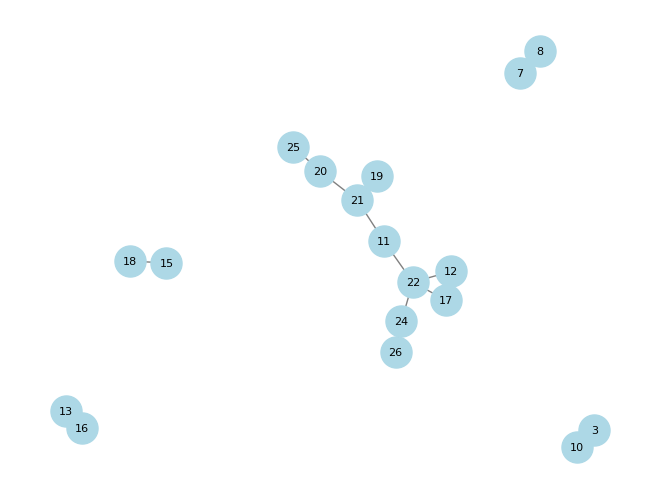

In [85]:
#  create  a new graph with only the nodes in cosy_nodes
cosy_G = nx.Graph()
cosy_G.add_nodes_from(cosy_nodes)

# Add edges from the deduplicated COSY data
for _, row in cosy_dedup.iterrows():
    cosy_G.add_edge(row['f1p_i'], row['f2p_i'])


# plot the graph
nx.draw(cosy_G, with_labels=True, node_color='lightblue', node_size=500, font_size=8, edge_color='gray')
plt.show()